In [1]:
# Customer Churn Prediction using Machine Learning

## Introduction
#Customer churn means when a customer stops using a company’s service.  
#In telecom companies, churn prediction is important because it helps the business identify customers who may leave and take actions to retain them.

#This project uses customer service, contract, and billing information to predict whether a customer will churn or not.

## Objective
#- Understand the structure of the customer churn dataset
#- Perform data cleaning and preprocessing
#- Analyze important factors affecting churn using EDA
#- Build a machine learning model to predict churn
#- Evaluate the model performance using classification metrics

## Algorithm Used
#**Logistic Regression** is used as the main algorithm because:
#- It is suitable for binary classification (Churn: Yes/No)
#- It is simple, fast, and explainable
#- It provides a strong baseline model for churn prediction

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_excel("../data/customer_data.xlsx")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

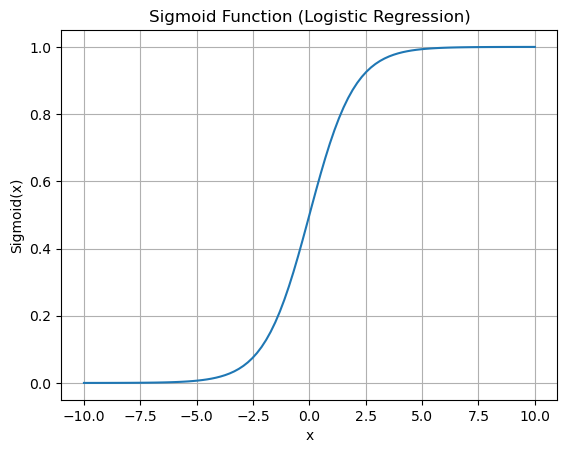

In [9]:
#Exploratory Data Analysis
#0) Sigmoid Curve
# Create x values
x = np.linspace(-10, 10, 100)

# Sigmoid function
y = 1 / (1 + np.exp(-x))

# Plot graph
plt.figure()
plt.plot(x, y)
plt.title("Sigmoid Function (Logistic Regression)")
plt.xlabel("x")
plt.ylabel("Sigmoid(x)")
plt.grid()

plt.show()

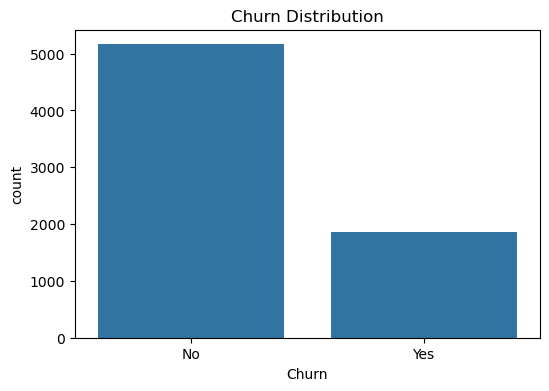

Churn
No     5163
Yes    1869
Name: count, dtype: int64

Percentage:
 Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [8]:
#1) Churn Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

print(df['Churn'].value_counts())
print("\nPercentage:\n", df['Churn'].value_counts(normalize=True) * 100)

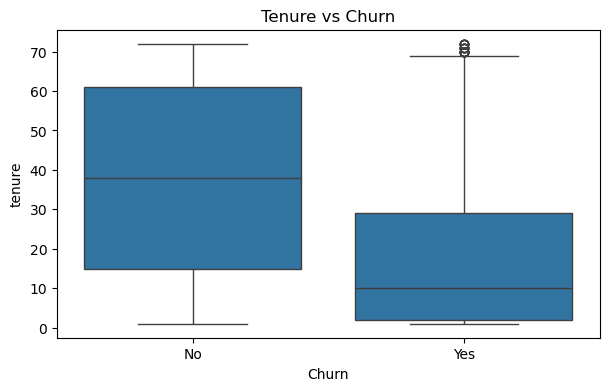

In [11]:
#2) Tenure vs Churn
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

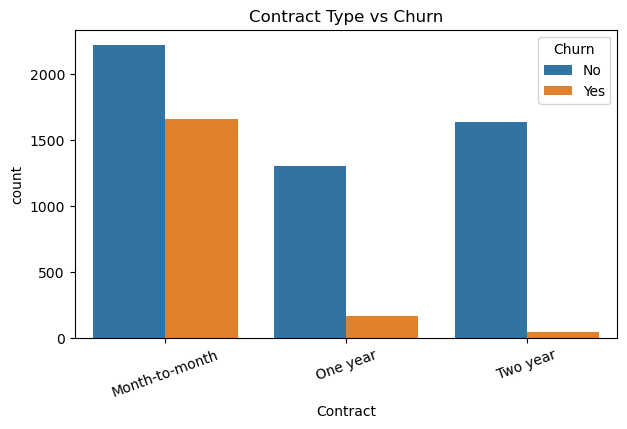

In [12]:
#3) Contract Type vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=20)
plt.show()

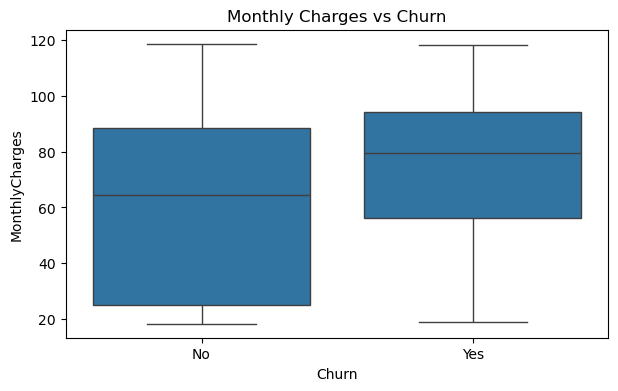

In [13]:
#4) Monthly Charges vs Churn
plt.figure(figsize=(7,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

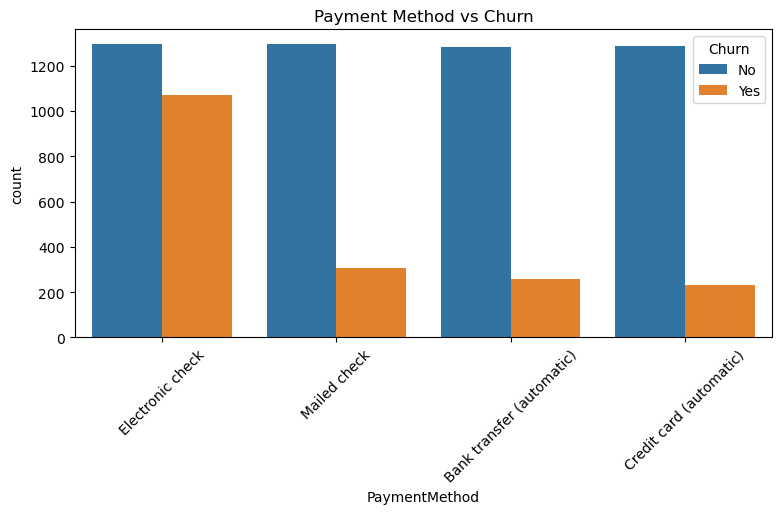

In [14]:
#5) Payment Method vs Churn
plt.figure(figsize=(9,4))
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

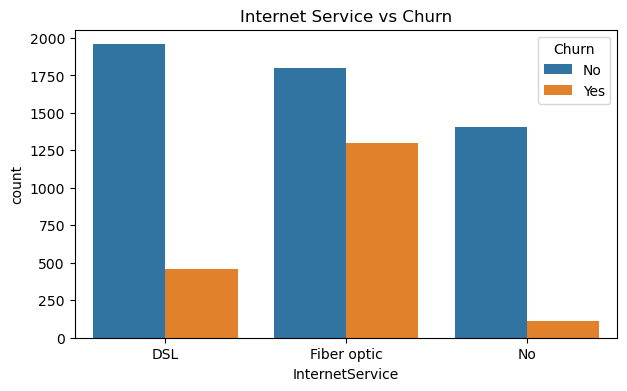

In [15]:
#6) Internet Service vs Churn
plt.figure(figsize=(7,4))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

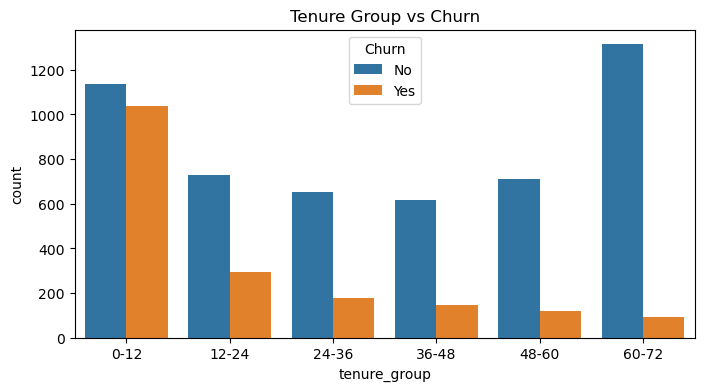

In [16]:
#7) Tenure bins vs churn
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,36,48,60,72],
                            labels=['0-12','12-24','24-36','36-48','48-60','60-72'])

plt.figure(figsize=(8,4))
sns.countplot(x='tenure_group', hue='Churn', data=df)
plt.title("Tenure Group vs Churn")
plt.xticks(rotation=0)
plt.show()

In [29]:
#logistic Regression Model

#Since customer-id is unique so it will not contribute in model train
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

In [30]:
#Encoding Target(Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [31]:
#One-Hot Encoding for categorical columns
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [32]:
#Split X and y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [33]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [34]:
#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
#Train Logistic Regression
#Version 1: Normal Logistic Regression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

#Predict
y_pred = log_model.predict(X_test_scaled)

In [36]:
#Evaluate (Accuracy + Confusion Matrix + F1)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8038379530916845
Confusion Matrix:
 [[916 117]
 [159 215]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [37]:
#Balanced Logistic Regression

log_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
log_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_balanced.predict(X_test_scaled)

print("Balanced Model Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Balanced Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("\nBalanced Classification Report:\n", classification_report(y_test, y_pred_bal))

Balanced Model Accuracy: 0.7263681592039801
Balanced Confusion Matrix:
 [[724 309]
 [ 76 298]]

Balanced Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [38]:
#The balanced Logistic Regression model improves churn recall significantly, but increases false positives. 
#The default model provides better overall accuracy with fewer false alarms. 
#Model choice depends on whether the priority is maximizing churn detection or minimizing unnecessary retention actions.

In [39]:
#Threshold Tuning (Logistic Regression)
#For normal
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]
#For balanced
y_prob_bal = log_balanced.predict_proba(X_test_scaled)[:, 1]

In [41]:
#Custom threshold function

def evaluate_threshold(y_true, y_probs, threshold):
    y_pred_thresh = (y_probs >= threshold).astype(int)
    precision = precision_score(y_true, y_pred_thresh)
    recall = recall_score(y_true, y_pred_thresh)
    f1 = f1_score(y_true, y_pred_thresh)
    return precision, recall, f1

In [42]:
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]

for t in thresholds:
    p, r, f1 = evaluate_threshold(y_test, y_prob, t)
    print(f"Threshold {t}: Precision={p:.2f}, Recall={r:.2f}, F1={f1:.2f}")

Threshold 0.3: Precision=0.51, Recall=0.76, F1=0.61
Threshold 0.35: Precision=0.54, Recall=0.72, F1=0.62
Threshold 0.4: Precision=0.58, Recall=0.68, F1=0.63
Threshold 0.45: Precision=0.60, Recall=0.63, F1=0.62
Threshold 0.5: Precision=0.65, Recall=0.57, F1=0.61
Threshold 0.55: Precision=0.67, Recall=0.49, F1=0.57


In [43]:
best_t = 0.4
y_pred_best = (y_prob >= best_t).astype(int)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

Confusion Matrix:
 [[846 187]
 [118 256]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.82      0.85      1033
           1       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407



In [44]:
#Threshold Tuning Result:
#By lowering the classification threshold from 0.5 to 0.4, the model achieved a better balance between precision and recall for churn prediction.
#This improved the F1-score for churn customers, making the model more useful for real-world retention strategies.

In [45]:
## Conclusion

#In this project, a complete machine learning pipeline was built to predict customer churn using Logistic Regression.  
#After cleaning and preprocessing the dataset, EDA showed that churn is influenced by factors like contract type, tenure, and monthly charges.

#The Logistic Regression model performed well as a baseline classifier. Since the dataset was imbalanced, threshold tuning was applied to improve churn detection.  
#By using a threshold of **0.4**, the model achieved a better balance between precision and recall, improving the churn class F1-score.

In [46]:
## Model Usage (Prediction)

#To predict churn for a new customer, the same preprocessing steps must be applied:
#- Convert `TotalCharges` to numeric (if needed)
#- Drop `customerID`
#- Apply one-hot encoding to categorical columns
#- Align feature columns with training data
#- Scale features using the trained scaler
#- Predict churn probability and classify using a threshold of **0.4**

In [47]:
# Save feature names for alignment
feature_names = X.columns

def predict_churn(new_customer_df):
    # One-hot encode
    new_encoded = pd.get_dummies(new_customer_df)
    
    # Align columns with training features
    new_encoded = new_encoded.reindex(columns=feature_names, fill_value=0)
    
    # Scale
    new_scaled = scaler.transform(new_encoded)
    
    # Probability of churn
    churn_prob = log_model.predict_proba(new_scaled)[:, 1][0]
    
    # Threshold-based prediction (0.4)
    churn_pred = int(churn_prob >= 0.4)
    
    return churn_pred, churn_prob

In [48]:
# Example new customer
new_customer = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 89.1,
    "TotalCharges": 445.5
}])

pred, prob = predict_churn(new_customer)

print("Churn Prediction (0=No, 1=Yes):", pred)
print("Churn Probability:", prob)

Churn Prediction (0=No, 1=Yes): 1
Churn Probability: 0.7501830298363478


In [50]:
#Note: The churn threshold was set to **0.4** to improve recall and overall churn detection performance.